# Paper examples 

This notebook provides the example code blocks illustrated in the `SNuDD` paper.

In [1]:
import numpy
import matplotlib.pyplot as plt


## Define an NSI model

In [2]:
from snudd.models import GeneralNSI

# Define NSI parameters
NSI_matrix = numpy.array([[0.0, 0.0, 0.0],
                          [0.0, 0.0, 0.1],
                          [0.0, 0.1, 0.0]])
NSI_eta = numpy.pi/4
NSI_phi = 0

# Create NSI model object
NSI_model = GeneralNSI(NSI_matrix, NSI_eta, NSI_phi)

## Compute neutrino density matrix

### Only solar density matrix

In [3]:
from snudd.nsi.nsi_probabilities import DensityMatrixCalculator

# Create probability calculator 
NSI_density_calculator = DensityMatrixCalculator(NSI_model)

# Calculate solar density matrix over neutrino energy range
Enus = numpy.geomspace(1e-6, 1e0, 200) # in GeV
solar_density = NSI_density_calculator.density(Enus, '8B')

# Returns an array of 3x3 denisty matrices evaluated over the Enus
numpy.shape(solar_density)

(200, 3, 3)

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

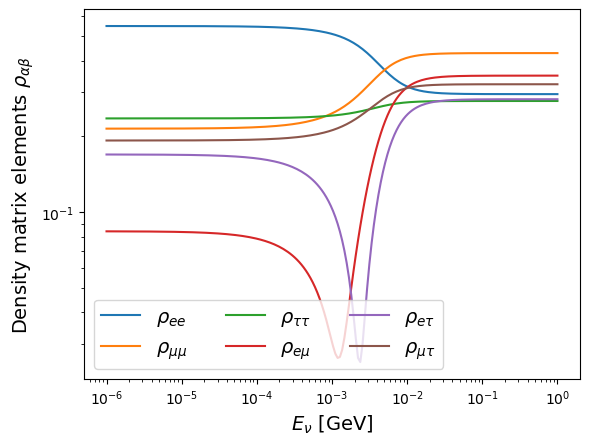

In [4]:
plt.loglog(Enus, abs(solar_density[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(Enus, abs(solar_density[:, 1,1]),  label=r'$\rho_{\mu\mu}$')
plt.loglog(Enus, abs(solar_density[:, 2,2]),  label=r'$\rho_{\tau\tau}$')
plt.loglog(Enus, abs(solar_density[:, 0,1]),  label=r'$\rho_{e\mu}$')
plt.loglog(Enus, abs(solar_density[:, 0,2]),  label=r'$\rho_{e\tau}$')
plt.loglog(Enus, abs(solar_density[:, 1,2]),  label=r'$\rho_{\mu\tau}$')

plt.legend(fontsize=14, ncol=3)

plt.ylabel(r'Density matrix elements $\rho_{\alpha\beta}$', size=14)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

### Combined solar + earth matter density matrix

In [7]:
from snudd.nsi.nsi_probabilities import DensityMatrixEarthCalculator

# Create probability calculator 
NSI_earth_calculator = DensityMatrixEarthCalculator(NSI_model)

# Calculate solar density matrix over neutrino energy range
Enus = numpy.geomspace(1e-6, 1e0, 200) # in GeV
cnadir = numpy.cos(numpy.pi/4)
earth_density = NSI_earth_calculator.density_earth(Enus, [cnadir], [1], nu='8B')

# Returns an array of 3x3 denisty matrices evaluated over the Enus
numpy.shape(earth_density)

(200, 3, 3)

Text(0.5, 0, '$E_{\\nu}\\,\\,\\left[{\\rm GeV}\\right]$')

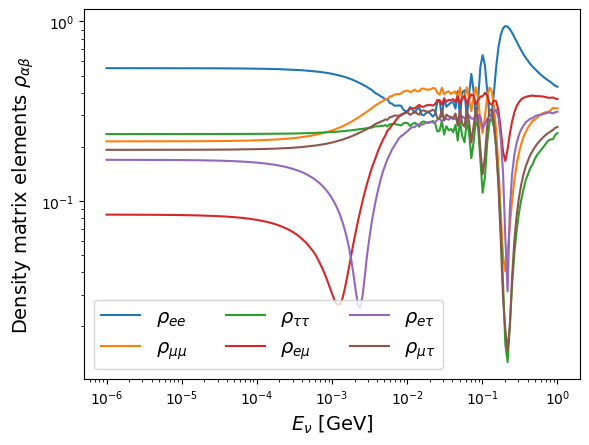

In [8]:
plt.loglog(Enus, abs(earth_density[:, 0,0]),  label=r'$\rho_{ee}$')
plt.loglog(Enus, abs(earth_density[:, 1,1]),  label=r'$\rho_{\mu\mu}$')
plt.loglog(Enus, abs(earth_density[:, 2,2]),  label=r'$\rho_{\tau\tau}$')
plt.loglog(Enus, abs(earth_density[:, 0,1]),  label=r'$\rho_{e\mu}$')
plt.loglog(Enus, abs(earth_density[:, 0,2]),  label=r'$\rho_{e\tau}$')
plt.loglog(Enus, abs(earth_density[:, 1,2]),  label=r'$\rho_{\mu\tau}$')

plt.legend(fontsize=14, ncol=3)

plt.ylabel(r'Density matrix elements $\rho_{\alpha\beta}$', size=14)
plt.xlabel(r'$E_{\nu}\,\,\left[{\rm GeV}\right]$', size=14)

## Nuclear recoil spectrum